In [2]:
import sys
import torch

sys.path.append('C:/Users/MSI LAPTOP/landmark-classifier')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")

Usando: cuda


In [3]:
from src.data import get_data_loaders

DATA_DIR = 'C:/Users/MSI LAPTOP/landmark_images/landmark_images'

train_loader, val_loader, test_loader, class_names = get_data_loaders(
    data_dir=DATA_DIR,
    batch_size=32,
    val_split=0.2,
    num_workers=2
)

Clases encontradas : 50
Imágenes en train  : 3997
Imágenes en val    : 999
Imágenes en test   : 1250


In [4]:
from src.model import get_transfer_model

model_resnet18 = get_transfer_model(
    model_name  = 'resnet18',
    num_classes = 50,
    device      = device
)

Modelo: resnet18
Parámetros totales    : 11,320,690
Parámetros entrenables: 144,178  (1.3%)


In [5]:
from src.train import train_transfer_model

history_resnet18 = train_transfer_model(
    model        = model_resnet18,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = device,
    epochs       = 15,
    lr           = 0.001,
    save_path    = 'C:/Users/MSI LAPTOP/landmark-classifier/models/best_resnet18.pt'
)

Época [01/15] | Train Loss: 3.4666  Acc: 15.0% | Val Loss: 2.5454  Acc: 46.7% ✓ mejor modelo
Época [02/15] | Train Loss: 2.5258  Acc: 36.8% | Val Loss: 1.9372  Acc: 55.0% ✓ mejor modelo
Época [03/15] | Train Loss: 2.1382  Acc: 44.8% | Val Loss: 1.7152  Acc: 55.1% ✓ mejor modelo
Época [04/15] | Train Loss: 1.9256  Acc: 50.0% | Val Loss: 1.5729  Acc: 59.1% ✓ mejor modelo
Época [05/15] | Train Loss: 1.7745  Acc: 53.2% | Val Loss: 1.5169  Acc: 59.1% ✓ mejor modelo
Época [06/15] | Train Loss: 1.7076  Acc: 55.2% | Val Loss: 1.4701  Acc: 62.2% ✓ mejor modelo
Época [07/15] | Train Loss: 1.6297  Acc: 56.2% | Val Loss: 1.3868  Acc: 64.3% ✓ mejor modelo
Época [08/15] | Train Loss: 1.5802  Acc: 58.4% | Val Loss: 1.3941  Acc: 62.9%
Época [09/15] | Train Loss: 1.5221  Acc: 58.3% | Val Loss: 1.3516  Acc: 63.7% ✓ mejor modelo
Época [10/15] | Train Loss: 1.4771  Acc: 59.7% | Val Loss: 1.3201  Acc: 65.4% ✓ mejor modelo
Época [11/15] | Train Loss: 1.4388  Acc: 61.1% | Val Loss: 1.3109  Acc: 65.5% ✓ mejor

In [ ]:
history_resnet18_2 = train_transfer_model(
    model        = model_resnet18,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = device,
    epochs       = 10,
    lr           = 0.0003,    # ← bajamos un poco el lr para afinar
    save_path    = 'C:/Users/MSI LAPTOP/landmark-classifier/models/best_resnet18.pt'
)

Época [01/10] | Train Loss: 1.4369  Acc: 60.7% | Val Loss: 1.3120  Acc: 65.4% ✓ mejor modelo
Época [02/10] | Train Loss: 1.4131  Acc: 62.3% | Val Loss: 1.3067  Acc: 65.5% ✓ mejor modelo
Época [03/10] | Train Loss: 1.3820  Acc: 62.2% | Val Loss: 1.2799  Acc: 66.8% ✓ mejor modelo
Época [04/10] | Train Loss: 1.3976  Acc: 62.6% | Val Loss: 1.2819  Acc: 66.2%
Época [05/10] | Train Loss: 1.3351  Acc: 64.1% | Val Loss: 1.2668  Acc: 66.8% ✓ mejor modelo
Época [06/10] | Train Loss: 1.3230  Acc: 63.6% | Val Loss: 1.2830  Acc: 66.3%
Época [07/10] | Train Loss: 1.3218  Acc: 64.7% | Val Loss: 1.2628  Acc: 66.9% ✓ mejor modelo
Época [08/10] | Train Loss: 1.3008  Acc: 64.6% | Val Loss: 1.2609  Acc: 67.3% ✓ mejor modelo
Época [09/10] | Train Loss: 1.2821  Acc: 65.4% | Val Loss: 1.2573  Acc: 66.5% ✓ mejor modelo
Época [10/10] | Train Loss: 1.2923  Acc: 64.5% | Val Loss: 1.2594  Acc: 66.6%

Entrenamiento finalizado. Mejor val_loss: 1.2573


In [8]:
# Descongelar las últimas 2 capas de ResNet18
for name, param in model_resnet18.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True

# Verificar cuántos parámetros entrenables ahora
trainable = sum(p.numel() for p in model_resnet18.parameters() if p.requires_grad)
print(f"Parámetros entrenables ahora: {trainable:,}")

# Entrenar con lr muy bajo para no destruir lo aprendido
history_resnet18_3 = train_transfer_model(
    model        = model_resnet18,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = device,
    epochs       = 10,
    lr           = 0.00005,   # ← muy bajo para fine-tuning
    save_path    = 'C:/Users/MSI LAPTOP/landmark-classifier/models/best_resnet18.pt'
)

Parámetros entrenables ahora: 8,537,906
Época [01/10] | Train Loss: 1.2656  Acc: 65.3% | Val Loss: 1.1777  Acc: 68.5% ✓ mejor modelo
Época [02/10] | Train Loss: 1.0791  Acc: 70.5% | Val Loss: 1.1003  Acc: 71.1% ✓ mejor modelo
Época [03/10] | Train Loss: 0.9082  Acc: 74.2% | Val Loss: 1.0620  Acc: 72.5% ✓ mejor modelo
Época [04/10] | Train Loss: 0.8129  Acc: 76.9% | Val Loss: 1.0201  Acc: 74.5% ✓ mejor modelo
Época [05/10] | Train Loss: 0.7341  Acc: 79.4% | Val Loss: 1.0011  Acc: 74.5% ✓ mejor modelo
Época [06/10] | Train Loss: 0.6687  Acc: 81.3% | Val Loss: 0.9981  Acc: 74.8% ✓ mejor modelo
Época [07/10] | Train Loss: 0.6254  Acc: 82.3% | Val Loss: 0.9942  Acc: 74.6% ✓ mejor modelo
Época [08/10] | Train Loss: 0.5818  Acc: 83.8% | Val Loss: 0.9917  Acc: 75.2% ✓ mejor modelo
Época [09/10] | Train Loss: 0.5522  Acc: 84.9% | Val Loss: 0.9818  Acc: 76.3% ✓ mejor modelo
Época [10/10] | Train Loss: 0.5369  Acc: 85.2% | Val Loss: 0.9879  Acc: 75.9%

Entrenamiento finalizado. Mejor val_loss: 0.

In [9]:
from src.train import evaluate_model

print("=== ResNet18 Test Accuracy ===")
acc_resnet18 = evaluate_model(model_resnet18, test_loader, device)

=== ResNet18 Test Accuracy ===
Test Accuracy: 77.68%


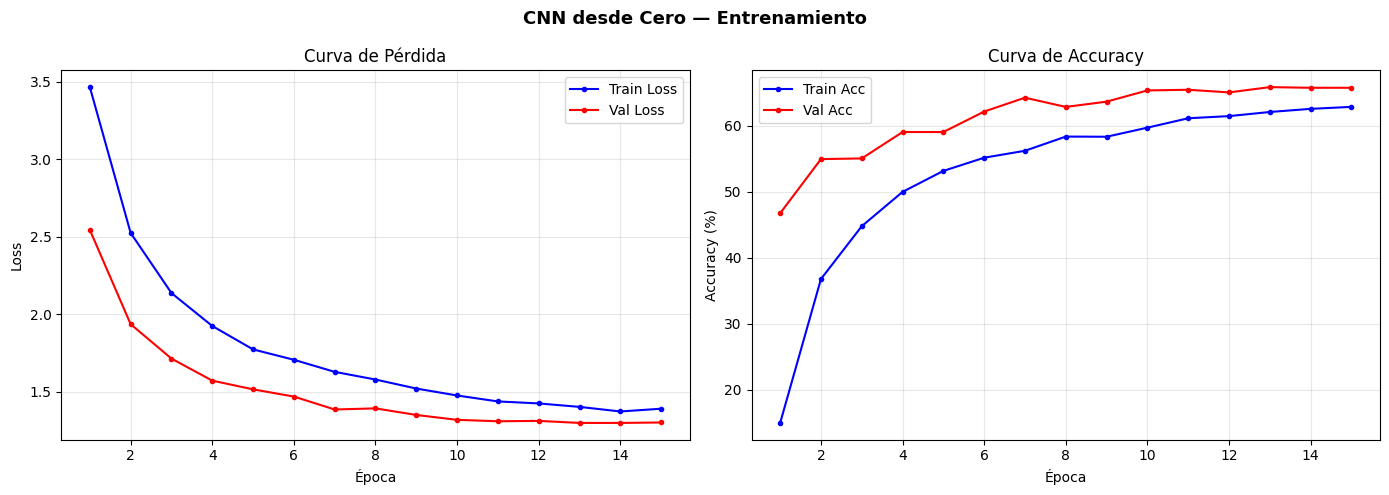

In [6]:
from src.train import plot_training_curves

plot_training_curves(history_resnet18)

In [10]:
model_resnet18.eval()

scripted = torch.jit.script(model_resnet18)
scripted.save('C:/Users/MSI LAPTOP/landmark-classifier/models/resnet18_scripted.pt')
print("Modelo exportado con TorchScript ✓")

Modelo exportado con TorchScript ✓


In [11]:
model_resnet50 = get_transfer_model(
    model_name  = 'resnet50',
    num_classes = 50,
    device      = device
)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\MSI LAPTOP/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:12<00:00, 8.35MB/s]


Modelo: resnet50
Parámetros totales    : 24,045,426
Parámetros entrenables: 537,394  (2.2%)


In [12]:
history_resnet50 = train_transfer_model(
    model        = model_resnet50,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = device,
    epochs       = 15,
    lr           = 0.001,
    save_path    = 'C:/Users/MSI LAPTOP/landmark-classifier/models/best_resnet50.pt'
)

Época [01/15] | Train Loss: 3.5941  Acc: 11.3% | Val Loss: 2.8561  Acc: 38.4% ✓ mejor modelo
Época [02/15] | Train Loss: 2.8093  Acc: 27.5% | Val Loss: 2.1849  Acc: 49.3% ✓ mejor modelo
Época [03/15] | Train Loss: 2.3821  Acc: 36.8% | Val Loss: 1.7818  Acc: 57.7% ✓ mejor modelo
Época [04/15] | Train Loss: 2.2252  Acc: 40.9% | Val Loss: 1.6978  Acc: 59.7% ✓ mejor modelo
Época [05/15] | Train Loss: 2.0629  Acc: 44.8% | Val Loss: 1.5530  Acc: 60.8% ✓ mejor modelo
Época [06/15] | Train Loss: 1.9621  Acc: 47.9% | Val Loss: 1.4666  Acc: 61.9% ✓ mejor modelo
Época [07/15] | Train Loss: 1.8759  Acc: 49.8% | Val Loss: 1.4231  Acc: 64.1% ✓ mejor modelo
Época [08/15] | Train Loss: 1.8621  Acc: 49.1% | Val Loss: 1.4165  Acc: 63.2% ✓ mejor modelo
Época [09/15] | Train Loss: 1.8242  Acc: 50.4% | Val Loss: 1.3804  Acc: 64.2% ✓ mejor modelo
Época [10/15] | Train Loss: 1.7517  Acc: 52.2% | Val Loss: 1.3388  Acc: 64.7% ✓ mejor modelo
Época [11/15] | Train Loss: 1.7202  Acc: 54.3% | Val Loss: 1.3206  Acc

In [13]:
for name, param in model_resnet50.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True

history_resnet50_2 = train_transfer_model(
    model        = model_resnet50,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = device,
    epochs       = 10,
    lr           = 0.00005,
    save_path    = 'C:/Users/MSI LAPTOP/landmark-classifier/models/best_resnet50.pt'
)

Época [01/10] | Train Loss: 1.5657  Acc: 56.9% | Val Loss: 1.1254  Acc: 69.1% ✓ mejor modelo
Época [02/10] | Train Loss: 1.2869  Acc: 63.6% | Val Loss: 1.0168  Acc: 72.5% ✓ mejor modelo
Época [03/10] | Train Loss: 1.1225  Acc: 68.0% | Val Loss: 0.9628  Acc: 73.9% ✓ mejor modelo
Época [04/10] | Train Loss: 0.9797  Acc: 72.3% | Val Loss: 0.9094  Acc: 74.5% ✓ mejor modelo
Época [05/10] | Train Loss: 0.8610  Acc: 74.9% | Val Loss: 0.9051  Acc: 74.8% ✓ mejor modelo
Época [06/10] | Train Loss: 0.7903  Acc: 77.0% | Val Loss: 0.8903  Acc: 76.3% ✓ mejor modelo
Época [07/10] | Train Loss: 0.7020  Acc: 80.2% | Val Loss: 0.8802  Acc: 77.1% ✓ mejor modelo
Época [08/10] | Train Loss: 0.6775  Acc: 80.5% | Val Loss: 0.8698  Acc: 77.6% ✓ mejor modelo
Época [09/10] | Train Loss: 0.6248  Acc: 81.6% | Val Loss: 0.8733  Acc: 77.8%
Época [10/10] | Train Loss: 0.6111  Acc: 82.1% | Val Loss: 0.8694  Acc: 77.4% ✓ mejor modelo

Entrenamiento finalizado. Mejor val_loss: 0.8694


In [14]:
print("=== ResNet50 Test Accuracy ===")
acc_resnet50 = evaluate_model(model_resnet50, test_loader, device)

=== ResNet50 Test Accuracy ===
Test Accuracy: 80.24%


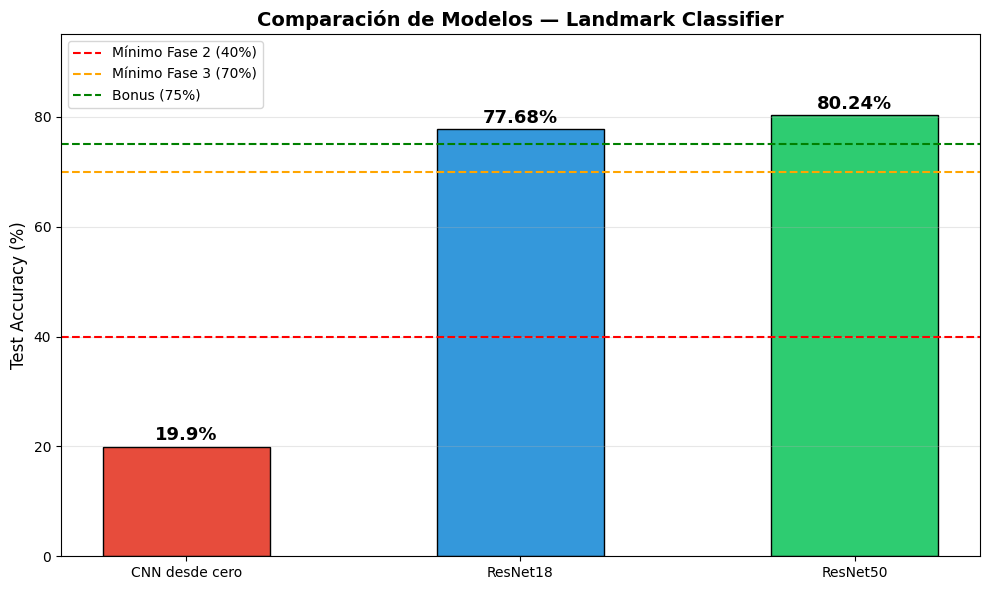


{'='*50}
Modelo                 Test Accuracy     Épocas
CNN desde cero                 19.9%        130
ResNet18                      77.68%         35
ResNet50                      80.24%         25


In [15]:
import matplotlib.pyplot as plt
import numpy as np

modelos = ['CNN desde cero', 'ResNet18', 'ResNet50']
test_acc = [19.9, 77.68, 80.24]
colores  = ['#e74c3c', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(modelos, test_acc, color=colores, width=0.5, edgecolor='black')

# Líneas de referencia
ax.axhline(y=40, color='red',    linestyle='--', linewidth=1.5, label='Mínimo Fase 2 (40%)')
ax.axhline(y=70, color='orange', linestyle='--', linewidth=1.5, label='Mínimo Fase 3 (70%)')
ax.axhline(y=75, color='green',  linestyle='--', linewidth=1.5, label='Bonus (75%)')

# Valores encima de las barras
for bar, acc in zip(bars, test_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Comparación de Modelos — Landmark Classifier', fontsize=14, fontweight='bold')
ax.set_ylim(0, 95)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla resumen
print("\n{'='*50}")
print(f"{'Modelo':<20} {'Test Accuracy':>15} {'Épocas':>10}")
print(f"{'='*50}")
print(f"{'CNN desde cero':<20} {'19.9%':>15} {'130':>10}")
print(f"{'ResNet18':<20} {'77.68%':>15} {'35':>10}")
print(f"{'ResNet50':<20} {'80.24%':>15} {'25':>10}")
print(f"{'='*50}")

In [16]:
model_resnet50.eval()
scripted50 = torch.jit.script(model_resnet50)
scripted50.save('C:/Users/MSI LAPTOP/landmark-classifier/models/resnet50_scripted.pt')
print("ResNet50 exportado con TorchScript ✓")

ResNet50 exportado con TorchScript ✓
